<a href="https://colab.research.google.com/github/chandBadal/AI_ML/blob/main/worksheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI-ML/data/Copy of devnagari digit.zip'
data_path = '/content/drive/MyDrive/AI-ML 2026/data'
destination_directory = os.path.dirname(data_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_directory)

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")

Successfully unzipped '/content/drive/MyDrive/AI-ML/data/Copy of devnagari digit.zip' to '/content/drive/MyDrive/AI-ML 2026'


x_train: (17000, 784)
y_train: (17000, 10)


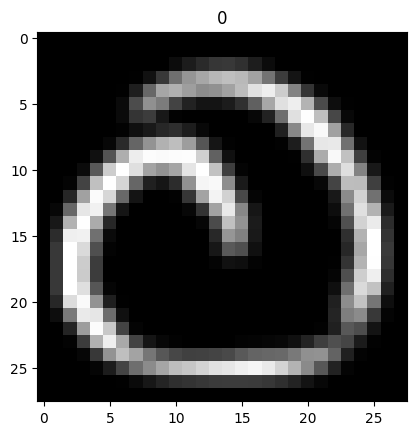

In [11]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI-ML 2026/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI-ML 2026/DevanagariHandwrittenDigitDataset/Test"

img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img) / 255.0

                images.append(img)
                labels.append(label)
            except:
                continue

    return np.array(images), np.array(labels)

x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

plt.imshow(x_train[0].reshape(28, 28), cmap='gray')
plt.title(np.argmax(y_train[0]))
plt.show()

In [12]:

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.15
)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8913 - loss: 0.3703 - val_accuracy: 0.2647 - val_loss: 7.4918
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9720 - loss: 0.0975 - val_accuracy: 0.2796 - val_loss: 8.3700
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9838 - loss: 0.0628 - val_accuracy: 0.2773 - val_loss: 8.1930
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9900 - loss: 0.0389 - val_accuracy: 0.3059 - val_loss: 8.0194
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9943 - loss: 0.0240 - val_accuracy: 0.2804 - val_loss: 8.9290
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9972 - loss: 0.0154 - val_accuracy: 0.2925 - val_loss: 9.7916
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9972 - loss: 0.0120 - val_accuracy: 0.2878 - val_loss: 10.4448
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9989 - loss: 0.0073 - val_accuracy

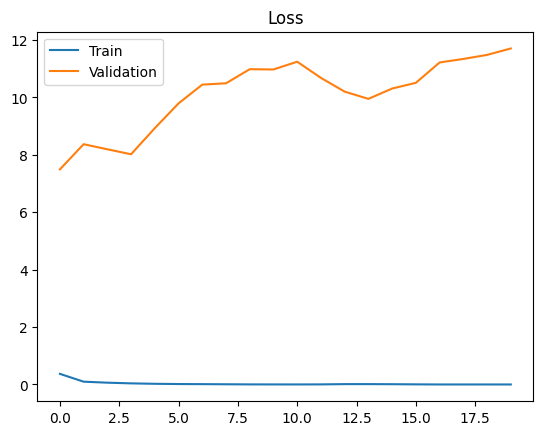

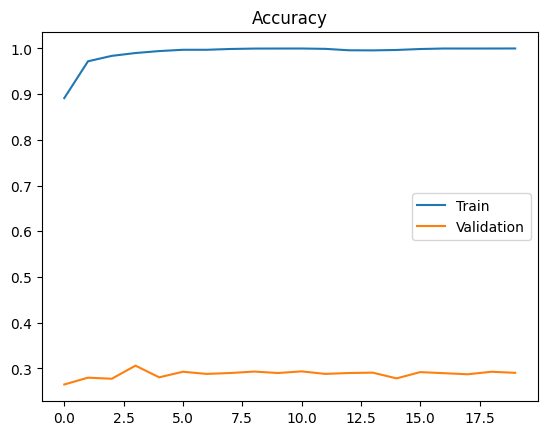

In [29]:
import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [14]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8850 - loss: 1.7861
Test accuracy: 0.8849999904632568


In [26]:
import os

save_path = "/content/drive/MyDrive/AI-ML/workshop4/model.keras"
save_dir = os.path.dirname(save_path)
os.makedirs(save_dir, exist_ok=True)

model.save(save_path)

In [27]:
from tensorflow.keras.models import load_model

loaded_model = load_model("/content/drive/MyDrive/AI-ML/workshop4/model.keras")
print("Model loaded successfully")

Model loaded successfully


In [28]:
pred_probs = model.predict(x_test)

pred_labels = np.argmax(pred_probs, axis=1)

true_labels = np.argmax(y_test, axis=1)

for i in range(10):
    print(f"Predicted: {pred_labels[i]}, Actual: {true_labels[i]}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
